# 📘 **Notebook 05 — Community Detection (Fraud Rings)**

---

## 🧠 What is Community Detection?

Community detection answers:

> “Which nodes form tightly connected groups in a graph?”

---

### 💡 Definition

A **community (or cluster)** is:

> A group of nodes that are more densely connected to each other than to the rest of the graph.

---

### 📊 Visualization

![Community Detection](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRmF7zxiHKXjYEwqGLN3qobwy6_dsZ4wPSXeg&s)

---

## 🔥 Why Communities Matter?

Real-world networks are **not random** — they form groups.

---

### 💡 Real-World Examples

| Domain         | Community Meaning                |
| -------------- | -------------------------------- |
| Social network | Friend groups                    |
| E-commerce     | Customer segments                |
| Telecom        | Calling circles                  |
| Fraud/AML      | Fraud rings / collusion networks |

---

## 🧠 Key Insight

> “Fraud rarely happens in isolation — it happens in groups.”

---

# 🕵️ Community Detection in Fraud

---

## 🚨 What is a Fraud Ring?

A fraud ring is:

> A group of accounts/entities working together to commit fraud.

---

### 💡 Example

```id="e1"
A — B — C  
|    |    |  
F — E — D
```

This tightly connected structure may indicate:

* Collusion
* Synthetic identities
* Coordinated transactions

---

### 🚨 Red Flags in Communities

* High internal connectivity
* Repeated interactions
* Cyclic patterns
* Shared devices / attributes

---

# 🔗 Types of Community Detection Approaches

---

## 🔹 1. Connected Components (Basic)

---

### 🧠 Definition

> Groups where nodes are reachable from each other

---

### 💡 Example

```id="e2"
(A, B, C)   (D, E)
```

---

### ⚡ When Useful?

* Detect **completely separate groups**
* Quick baseline clustering

---

### 🚨 Limitation

❌ Cannot detect **sub-communities within large graphs**

---

# 🔹 2. Label Propagation

---

## 🧠 Intuition

> Nodes adopt the label of the majority of their neighbors

---

### 🔄 How It Works

1. Assign each node a unique label
2. Each node updates its label based on neighbors
3. Over time → communities emerge

---

### 📊 Visualization

![Label Propagation](https://dist.neo4j.com/wp-content/uploads/20190226091707/label-propagation-graph-algorithm-1.png)

---

## ⚡ Key Properties

✅ Fast and scalable
✅ No need to predefine number of clusters

---

## 🚨 Fraud Insight

* Useful for detecting **large fraud rings quickly**
* Works well in **streaming systems**

---

# 🔹 3. Modularity & Louvain Algorithm

---

## 🧠 What is Modularity?

> A measure of how well a graph is divided into communities

---

### 💡 Intuition

* High modularity:

  * Dense connections within groups
  * Sparse connections between groups

---

## 🔹 Louvain Algorithm

---

### 🧠 Intuition

> Optimizes modularity to find the best community structure

---

### 📊 Visualization

![Louvain Method](https://dist.neo4j.com/wp-content/uploads/20190315074208/louvain-modularity-algorithm-2.png)

---

## ⚡ Why It’s Important

✅ Industry-standard algorithm
✅ Works well on large graphs
✅ Produces high-quality communities

---

## 🚨 Fraud Insight (Very Important)

Louvain is widely used to:

* Detect **fraud rings**
* Identify **coordinated groups**
* Cluster **mule account networks**

---

# 🔹 4. Overlapping Communities (Advanced Concept)

---

## 🧠 Idea

> A node can belong to multiple communities

---

### 💡 Example

* A user:

  * Personal network
  * Business network

---

## 🚨 Fraud Insight

* A mule account may:

  * Participate in multiple fraud rings
* Very important for advanced AML systems

---

# ⚖️ Comparison of Methods

---

| Method               | Speed     | Accuracy | Use Case           |
| -------------------- | --------- | -------- | ------------------ |
| Connected Components | Fast      | Low      | Basic grouping     |
| Label Propagation    | Very Fast | Medium   | Large graphs       |
| Louvain              | Medium    | High     | Production systems |

---

# 🧠 Mental Models

---

### 🔹 Connected Components

👉 “Separate islands”

---

### 🔹 Label Propagation

👉 “People follow their neighbors”

---

### 🔹 Louvain

👉 “Find the best grouping structure”

---

# 🔥 End-to-End Fraud Example

---

## 🕵️ Scenario

Transaction graph:

```id="e3"
A — B — C  
|    |    |  
F — E — D  

G — H
```

---

## 🔍 Analysis

* Community 1:

```id="e4"
A, B, C, D, E, F
```

* Community 2:

```id="e5"
G, H
```

---

## 🚨 Insight

* Large dense cluster → potential fraud ring
* Small cluster → possibly benign

---

# 📊 Community-Level Features

Instead of node-level analysis, we can compute:

* Community size
* % of fraudulent nodes in community
* Density of connections
* Number of triangles

---

## 💡 Example Features

* “User belongs to high-risk community”
* “Community fraud ratio = 0.8”
* “Cluster size > threshold”

---

# 🧠 Why This Matters for ML

Community detection helps:

* Generate **powerful features**
* Improve fraud detection models
* Detect **group-level anomalies**


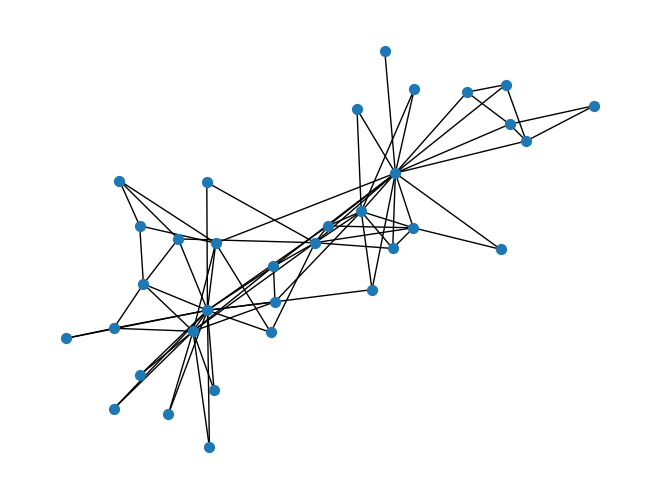

In [5]:
## 🔹 Create Graph

import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
nx.draw(G, node_size=50 )
plt.show()


In [6]:
## 🔹 Connected Components

components = list(nx.connected_components(G))
print("Components:", components)


Components: [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}]


In [7]:
## 🔹 Label Propagation

communities = nx.algorithms.community.label_propagation_communities(G)
communities = list(communities)

print("Communities:", communities)




Communities: [{0, 1, 3, 4, 7, 10, 11, 12, 13, 17, 19, 21, 24, 25, 31}, {32, 33, 2, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 28, 29, 30}, {16, 5, 6}]


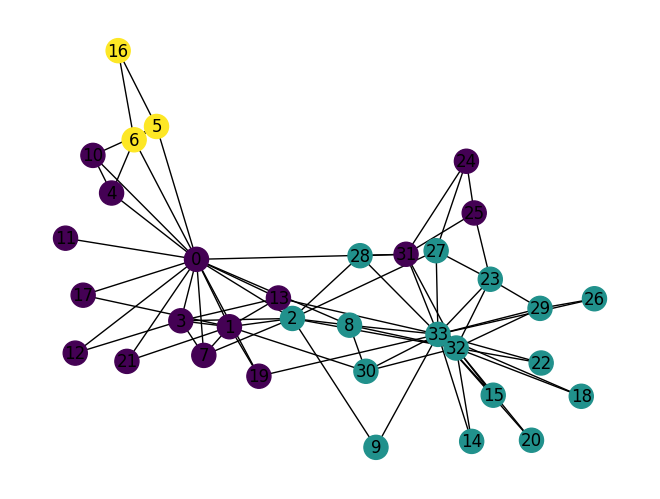

In [9]:
## 🔹 Visualize Communities

color_map = []
for node in G:
    for i, comm in enumerate(communities):
        if node in comm:
            color_map.append(i)

nx.draw(G, node_color=color_map, with_labels=True)
plt.show()


## 💡 Fraud Insight
# Clusters = potential fraud rings





# 🧩 Summary

* Communities = clusters of tightly connected nodes
* Connected components → basic grouping
* Label propagation → fast clustering
* Louvain → industry standard
* Critical for fraud detection

---

### ❓ Interview Questions

* What is modularity?
* Why is Louvain preferred in large graphs?
* Difference between connected components and community detection?
* Can a node belong to multiple communities?

---

### 🧪 Mini Exercise Idea

* Detect communities in a graph
* Identify:

  * Largest cluster
  * Most dense cluster
  * Cluster with highest fraud ratio